# Federated Learning with 100 Clients using FedAvg
This notebook simulates federated learning with 100 clients using the Federated Averaging (FedAvg) algorithm.

In [100]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import os
from tqdm import tqdm

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.10.0


In [101]:
# GPU Configuration
print("=" * 60)
print("GPU CONFIGURATION")
print("=" * 60)
print(f"TensorFlow version: {tf.__version__}")
print(f"Num GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ GPU detected and configured")
    except RuntimeError as e:
        print(f"GPU configuration error: {e}")
else:
    print("⚠ No GPU detected - Running on CPU")
print("=" * 60 + "\n")

GPU CONFIGURATION
TensorFlow version: 2.10.0
Num GPUs Available: 1
✓ GPU detected and configured



## Configuration

In [102]:
# Federated Learning Configuration
NUM_CLIENTS = 100
NUM_ROUNDS = 100
LOCAL_EPOCHS = 10
BATCH_SIZE = 32

# Directories
DATA_DIR = 'mnist_100_clients'
RESULTS_DIR = 'results_federated'
os.makedirs(RESULTS_DIR, exist_ok=True)

print("=" * 60)
print("FEDERATED LEARNING CONFIGURATION")
print("=" * 60)
print(f"Number of Clients: {NUM_CLIENTS}")
print(f"Communication Rounds: {NUM_ROUNDS}")
print(f"Local Epochs per Round: {LOCAL_EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Data Directory: {DATA_DIR}/")
print(f"Results Directory: {RESULTS_DIR}/")
print("=" * 60 + "\n")

FEDERATED LEARNING CONFIGURATION
Number of Clients: 100
Communication Rounds: 100
Local Epochs per Round: 10
Batch Size: 32
Data Directory: mnist_100_clients/
Results Directory: results_federated/



## Load Data

In [103]:
# Load test data (common for all clients)
print("Loading common test dataset...")
test_file = os.path.join(DATA_DIR, 'test_500_samples.npz')
test_data = np.load(test_file)

x_test = test_data['x'] / 255.0
y_test = test_data['y']
x_test = x_test.reshape(len(x_test), 28*28)

print(f"✓ Test data loaded: {x_test.shape}")
print(f"  Labels shape: {y_test.shape}")

Loading common test dataset...
✓ Test data loaded: (500, 784)
  Labels shape: (500,)


In [104]:
# Load all client data
print(f"\nLoading data for {NUM_CLIENTS} clients...")
client_data = []

for client_id in range(1, NUM_CLIENTS + 1):
    client_file = os.path.join(DATA_DIR, f'client_{client_id}.npz')
    data = np.load(client_file)
    
    x_client = data['x'] / 255.0
    y_client = data['y']
    x_client = x_client.reshape(len(x_client), 28*28)
    
    client_data.append({
        'x_train': x_client,
        'y_train': y_client,
        'x_test': x_test,
        'y_test': y_test
    })
    
    if client_id % 20 == 0:
        print(f"  Loaded {client_id}/{NUM_CLIENTS} clients")

print(f"\n✓ All {NUM_CLIENTS} clients loaded successfully")
print(f"  Each client has {len(client_data[0]['x_train'])} training samples")
print(f"  Common test set: {len(x_test)} samples")


Loading data for 100 clients...
  Loaded 20/100 clients
  Loaded 40/100 clients
  Loaded 60/100 clients
  Loaded 80/100 clients
  Loaded 100/100 clients

✓ All 100 clients loaded successfully
  Each client has 100 training samples
  Common test set: 500 samples


## Model Architecture

In [105]:
# Define model (same architecture as normal training)
def create_model():
    """Lightweight model optimized for small datasets"""
    model = keras.Sequential([
        keras.layers.Dense(64, input_shape=(784,), activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(10, activation="softmax")
    ])
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Test model creation
print("Testing model architecture...")
test_model = create_model()
test_model.summary()
print("\n✓ Model architecture validated")

Testing model architecture...
Model: "sequential_12247"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_36741 (Dense)         (None, 64)                50240     
                                                                 
 dropout_24494 (Dropout)     (None, 64)                0         
                                                                 
 dense_36742 (Dense)         (None, 32)                2080      
                                                                 
 dropout_24495 (Dropout)     (None, 32)                0         
                                                                 
 dense_36743 (Dense)         (None, 10)                330       
                                                                 
Total params: 52,650
Trainable params: 52,650
Non-trainable params: 0
_________________________________________________________________

✓ Model archite

## Federated Learning Functions

In [106]:
# Federated Averaging function
def federated_averaging(weights_list):
    """Average weights from all clients (FedAvg)"""
    avg_weights = []
    for weights_tuple in zip(*weights_list):
        avg_weights.append(np.mean(weights_tuple, axis=0))
    return avg_weights

print("✓ Federated averaging function defined")

✓ Federated averaging function defined


## Federated Training

In [107]:
# Initialize global model
print("\n" + "=" * 60)
print("INITIALIZING FEDERATED LEARNING")
print("=" * 60)

global_model = create_model()
global_weights = global_model.get_weights()

# Tracking arrays
client_train_acc_history = [[] for _ in range(NUM_CLIENTS)]  # Training accuracy per client per round
client_test_acc_history = [[] for _ in range(NUM_CLIENTS)]   # Test accuracy per client per round

print("✓ Global model initialized")
print("✓ Tracking arrays created")


INITIALIZING FEDERATED LEARNING
✓ Global model initialized
✓ Tracking arrays created


In [108]:
# Main federated training loop
print("\n" + "=" * 60)
print("STARTING FEDERATED TRAINING")
print("=" * 60 + "\n")

for round_num in tqdm(range(NUM_ROUNDS), desc="Communication Rounds", unit="round"):
    print(f"\n{'='*60}")
    print(f"ROUND {round_num + 1}/{NUM_ROUNDS}")
    print(f"{'='*60}")
    
    local_weights = []
    round_train_accs = []
    round_test_accs = []
    
    # Train each client with progress bar
    for client_id in tqdm(range(NUM_CLIENTS), desc=f"Training Clients (Round {round_num + 1})", 
                         unit="client", leave=False):
        # Create fresh model for this client
        client_model = create_model()
        
        # Set global weights
        client_model.set_weights(global_weights)
        
        # Get client's data
        x_train = client_data[client_id]['x_train']
        y_train = client_data[client_id]['y_train']
        x_test = client_data[client_id]['x_test']
        y_test = client_data[client_id]['y_test']
        
        # Train locally
        history = client_model.fit(
            x_train, y_train,
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )
        
        # Get final training accuracy
        train_acc = history.history['accuracy'][-1]
        
        # Evaluate on test data
        _, test_acc = client_model.evaluate(x_test, y_test, verbose=0)
        
        # Store accuracies
        client_train_acc_history[client_id].append(train_acc)
        client_test_acc_history[client_id].append(test_acc)
        round_train_accs.append(train_acc)
        round_test_accs.append(test_acc)
        
        # Collect weights
        local_weights.append(client_model.get_weights())
    
    # Federated averaging
    global_weights = federated_averaging(local_weights)
    global_model.set_weights(global_weights)
    
    # Round summary
    avg_train_acc = np.mean(round_train_accs) * 100
    avg_test_acc = np.mean(round_test_accs) * 100
    min_test_acc = np.min(round_test_accs) * 100
    max_test_acc = np.max(round_test_accs) * 100
    
    print(f"\n📊 Round {round_num + 1} Summary:")
    print(f"   Avg Training Accuracy: {avg_train_acc:.2f}%")
    print(f"   Avg Test Accuracy: {avg_test_acc:.2f}%")
    print(f"   Test Accuracy Range: [{min_test_acc:.2f}%, {max_test_acc:.2f}%]")

print("\n" + "="*60)
print("FEDERATED TRAINING COMPLETE!")
print("="*60 + "\n")


STARTING FEDERATED TRAINING



Communication Rounds:   0%|          | 0/100 [00:00<?, ?round/s]


ROUND 1/100


Communication Rounds:   1%|          | 1/100 [00:51<1:24:51, 51.43s/round]


📊 Round 1 Summary:
   Avg Training Accuracy: 49.02%
   Avg Test Accuracy: 48.86%
   Test Accuracy Range: [41.40%, 56.60%]

ROUND 2/100


...


📊 Round 98 Summary:
   Avg Training Accuracy: 98.25%
   Avg Test Accuracy: 92.77%
   Test Accuracy Range: [90.40%, 94.20%]

ROUND 99/100


Communication Rounds:  99%|█████████▉| 99/100 [1:28:26<00:57, 57.51s/round]


📊 Round 99 Summary:
   Avg Training Accuracy: 98.32%
   Avg Test Accuracy: 92.79%
   Test Accuracy Range: [89.80%, 94.20%]

ROUND 100/100


Communication Rounds: 100%|██████████| 100/100 [1:29:24<00:00, 53.64s/round]


📊 Round 100 Summary:
   Avg Training Accuracy: 98.35%
   Avg Test Accuracy: 92.79%
   Test Accuracy Range: [90.60%, 94.40%]

FEDERATED TRAINING COMPLETE!



## Results Analysis

In [109]:
# Calculate final accuracies
final_train_accs = [client_train_acc_history[i][-1] * 100 for i in range(NUM_CLIENTS)]
final_test_accs = [client_test_acc_history[i][-1] * 100 for i in range(NUM_CLIENTS)]

avg_final_train = np.mean(final_train_accs)
avg_final_test = np.mean(final_test_accs)

print("=" * 60)
print("FINAL RESULTS")
print("=" * 60)
print(f"Average Final Training Accuracy: {avg_final_train:.2f}%")
print(f"Average Final Test Accuracy: {avg_final_test:.2f}%")
print(f"Training Accuracy Range: [{np.min(final_train_accs):.2f}%, {np.max(final_train_accs):.2f}%]")
print(f"Test Accuracy Range: [{np.min(final_test_accs):.2f}%, {np.max(final_test_accs):.2f}%]")
print("=" * 60)

FINAL RESULTS
Average Final Training Accuracy: 98.35%
Average Final Test Accuracy: 92.79%
Training Accuracy Range: [95.00%, 100.00%]
Test Accuracy Range: [90.60%, 94.40%]


## Visualization

Creating training accuracy plot for 100 clients...
✓ Saved: results_federated\training_accuracy_100_clients.png


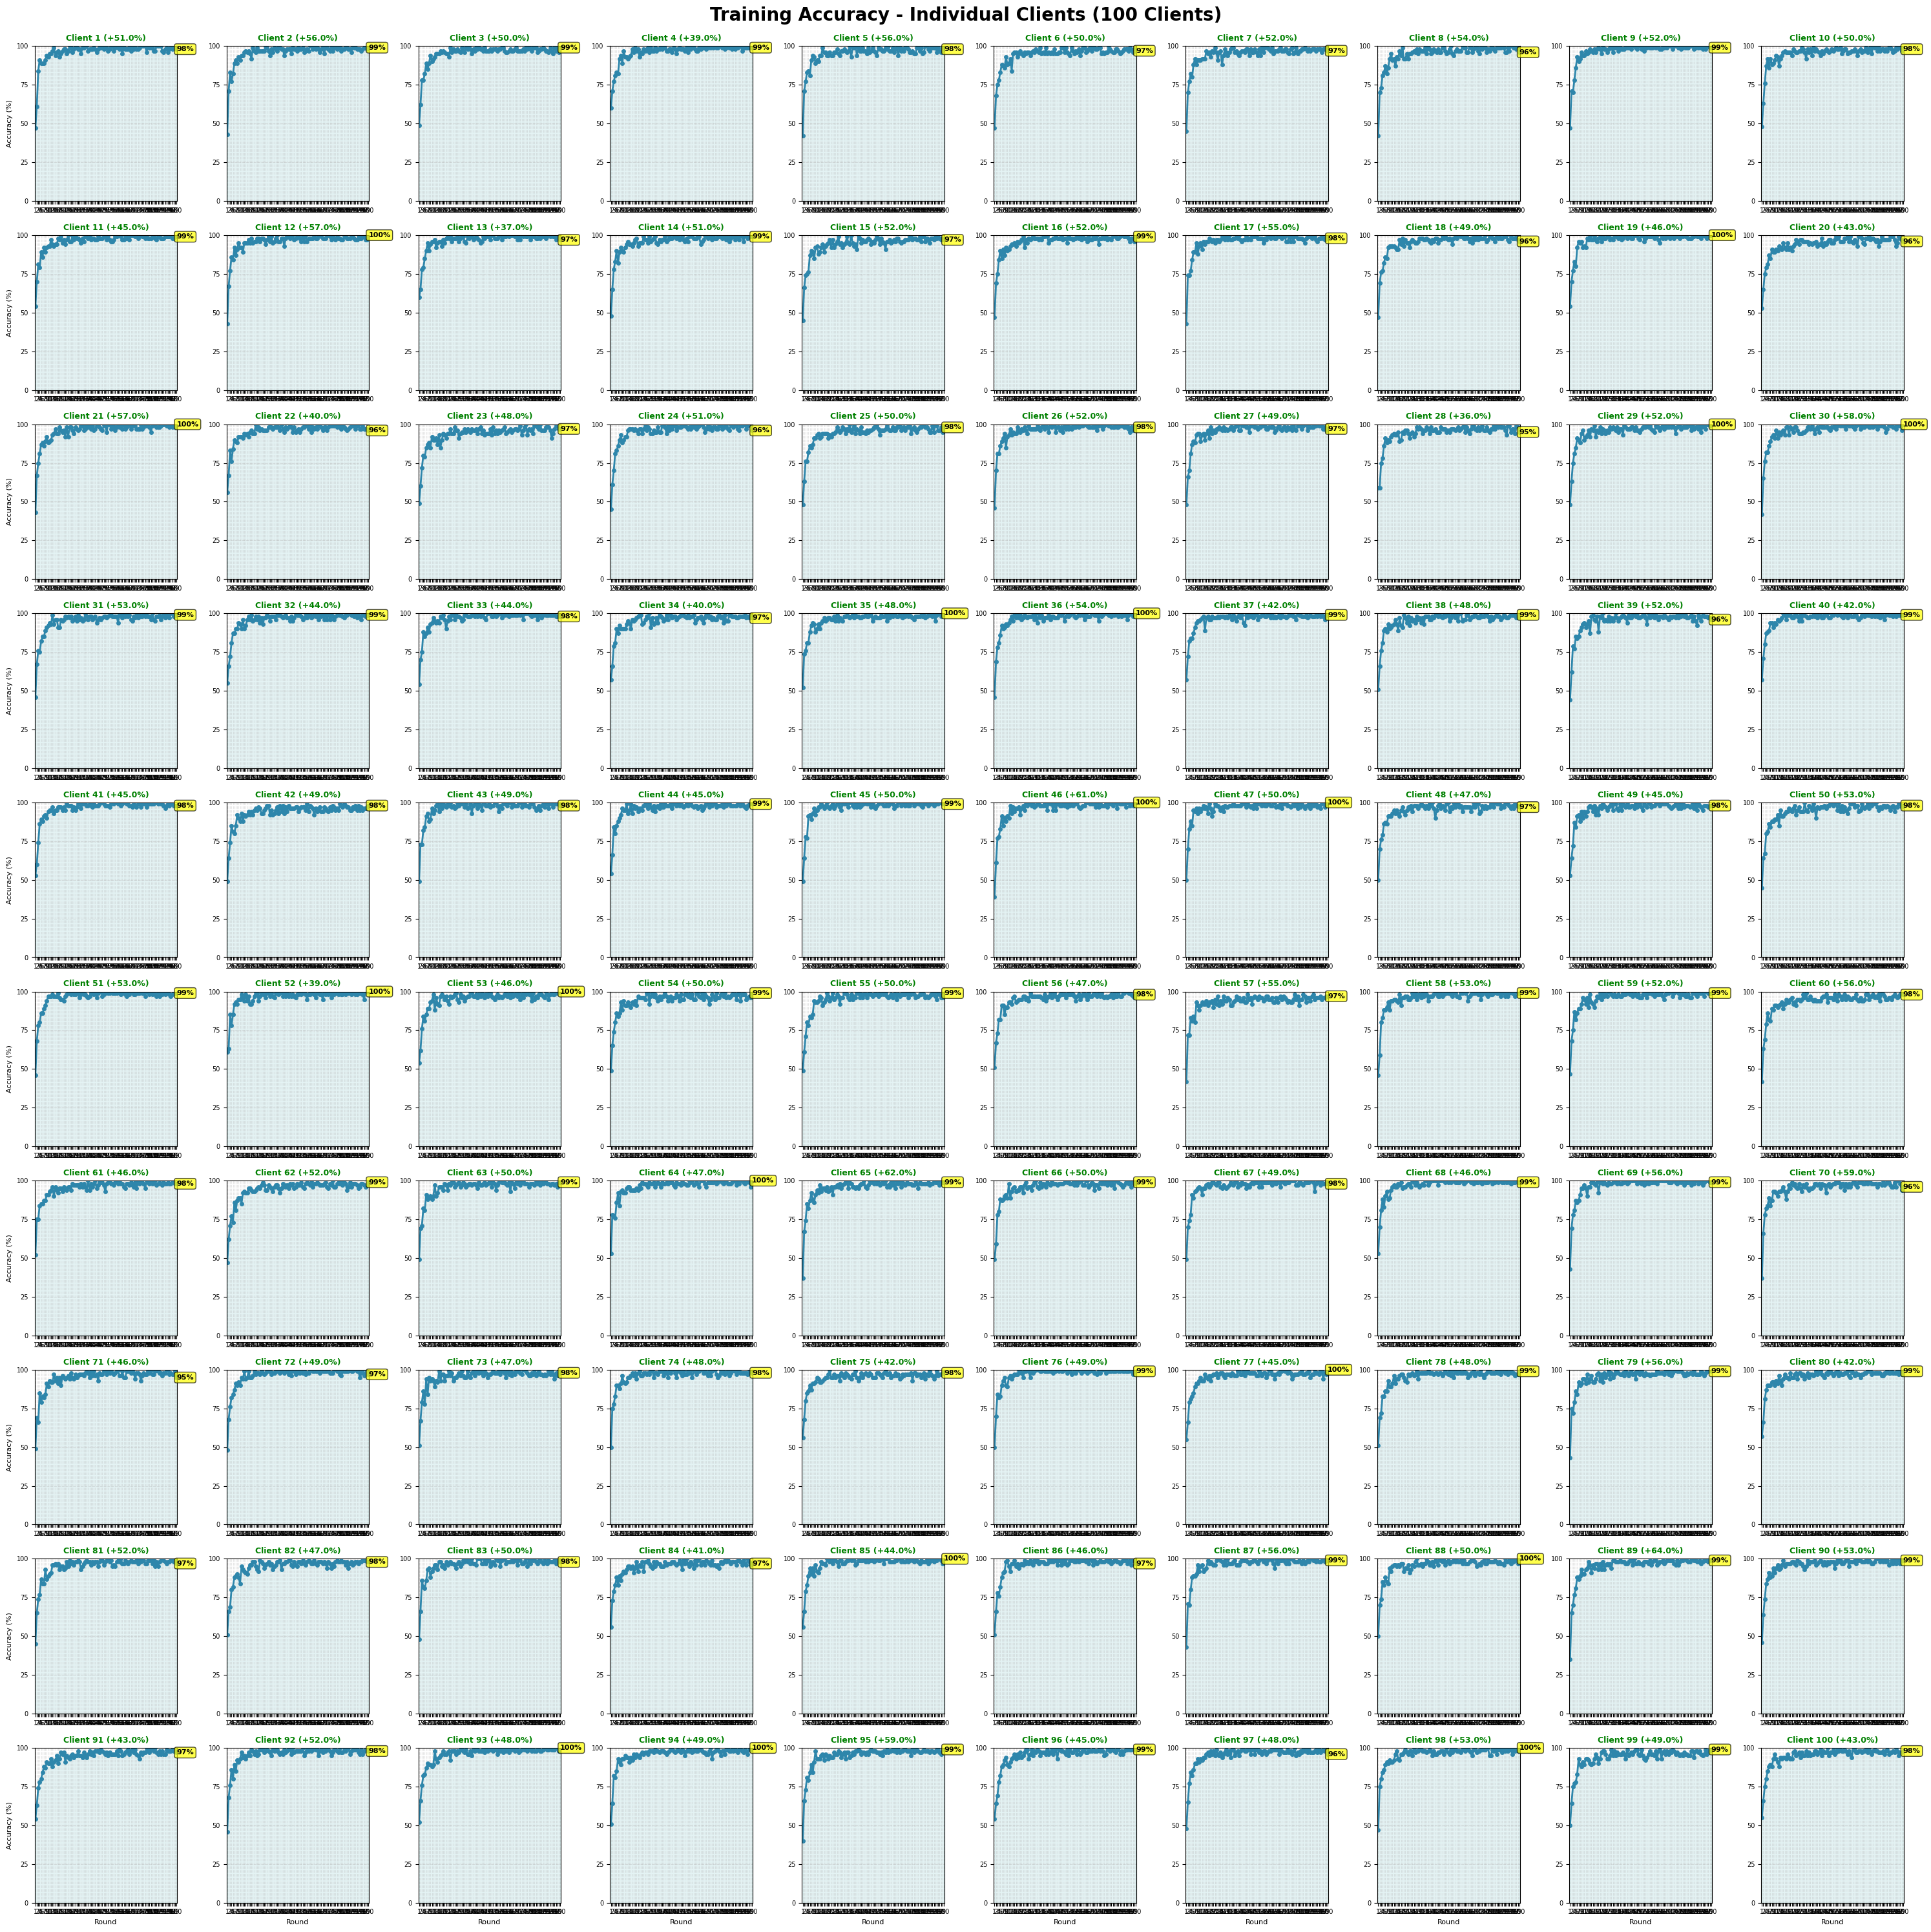

In [110]:
# Plot 1: Individual Training Accuracy for Each Client (Grid of Subplots)
print("Creating training accuracy plot for 100 clients...")

# Create a 10x10 grid of subplots
fig, axes = plt.subplots(10, 10, figsize=(30, 30))
fig.suptitle('Training Accuracy - Individual Clients (100 Clients)', fontsize=20, fontweight='bold', y=0.995)

rounds = range(1, NUM_ROUNDS + 1)

for client_id in range(NUM_CLIENTS):
    row = client_id // 10
    col = client_id % 10
    ax = axes[row, col]
    
    # Get training accuracies for this client
    train_accs = [acc * 100 for acc in client_train_acc_history[client_id]]
    final_acc = train_accs[-1]
    
    # Calculate improvement from first to last round
    improvement = final_acc - train_accs[0]
    
    # Plot with markers
    ax.plot(rounds, train_accs, marker='o', linewidth=2, markersize=4, color='#2E86AB')
    ax.fill_between(rounds, train_accs, alpha=0.3, color='#A8DADC')
    
    # Set title with client ID and final accuracy
    ax.set_title(f'Client {client_id+1} ({improvement:+.1f}%)', fontsize=9, fontweight='bold', color='green')
    
    # Add final accuracy text
    ax.text(NUM_ROUNDS, final_acc, f'{final_acc:.0f}%', 
            fontsize=8, fontweight='bold', verticalalignment='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    # Formatting
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, 100)
    ax.set_xlim(0.5, NUM_ROUNDS + 0.5)
    ax.set_xticks(rounds)
    ax.set_xticklabels(rounds, fontsize=7)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(['0', '25', '50', '75', '100'], fontsize=7)
    
    # Labels only on edges
    if row == 9:
        ax.set_xlabel('Round', fontsize=8)
    if col == 0:
        ax.set_ylabel('Accuracy (%)', fontsize=8)

plt.tight_layout()
train_plot_path = os.path.join(RESULTS_DIR, 'training_accuracy_100_clients.png')
plt.savefig(train_plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {train_plot_path}")
plt.show()

Creating test accuracy plot for 100 clients...
✓ Saved: results_federated\test_accuracy_100_clients.png


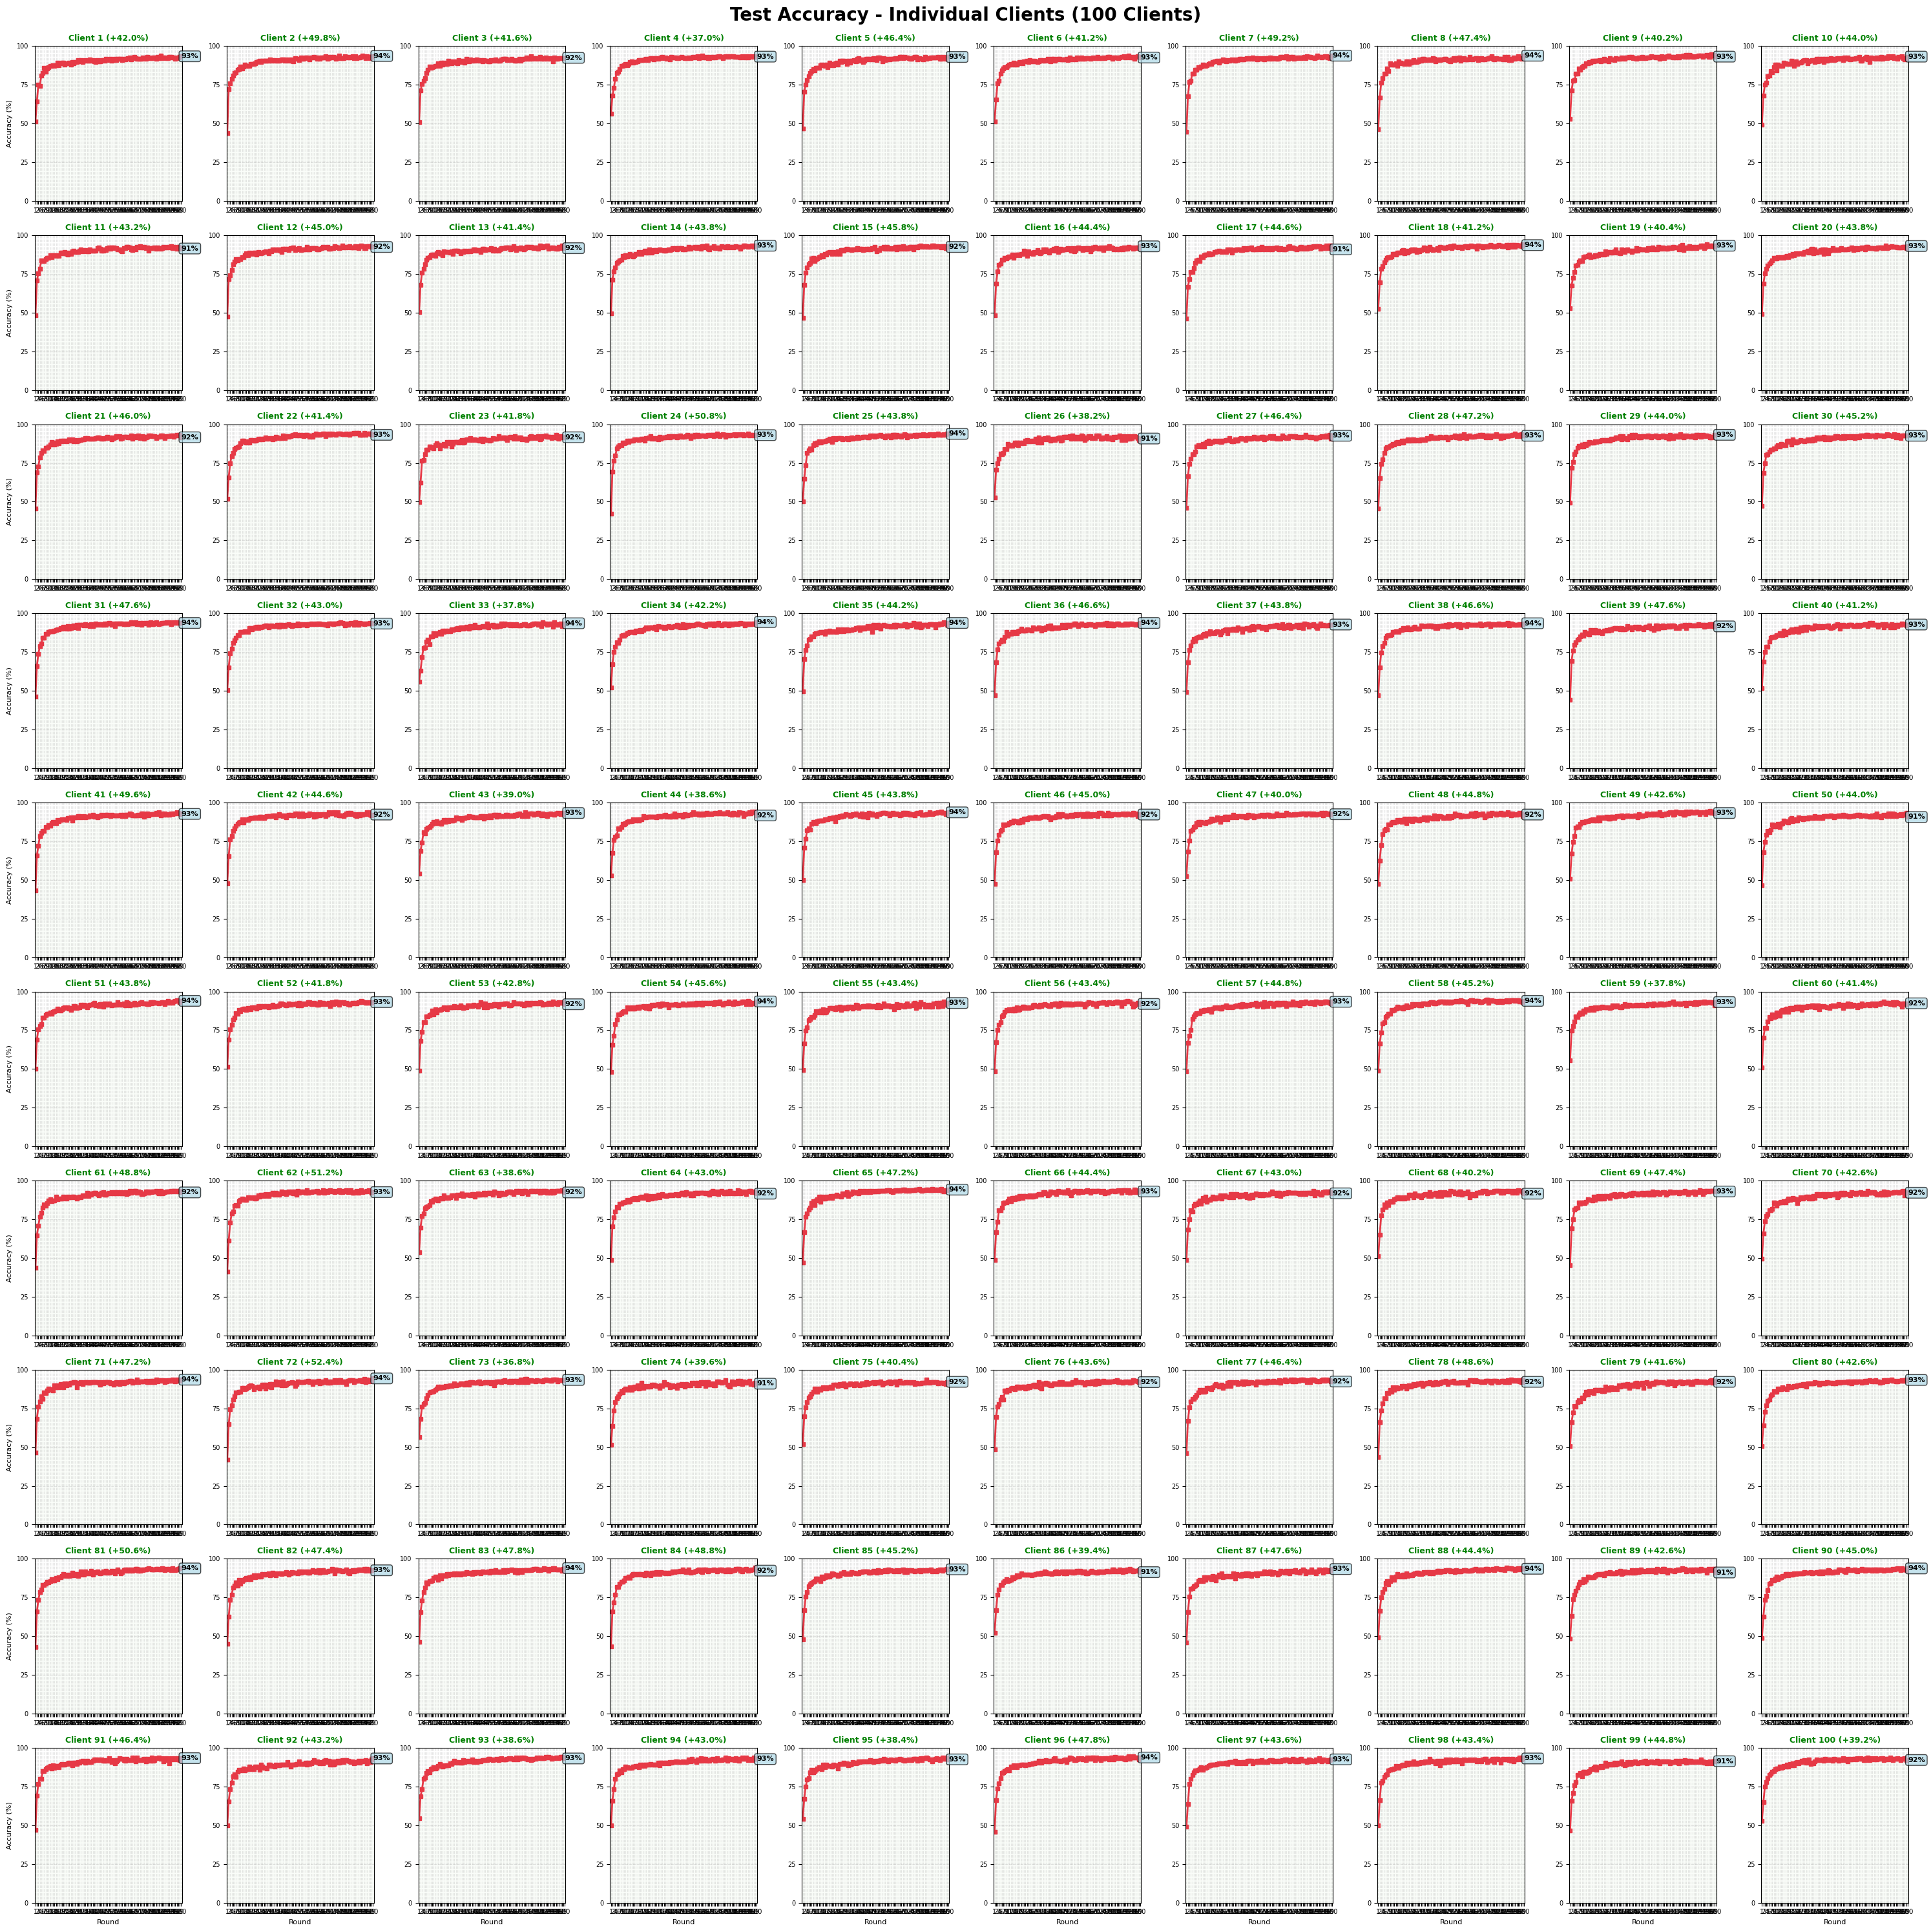

In [111]:
# Plot 2: Individual Test Accuracy for Each Client (Grid of Subplots)
print("Creating test accuracy plot for 100 clients...")

# Create a 10x10 grid of subplots
fig, axes = plt.subplots(10, 10, figsize=(30, 30))
fig.suptitle('Test Accuracy - Individual Clients (100 Clients)', fontsize=20, fontweight='bold', y=0.995)

rounds = range(1, NUM_ROUNDS + 1)

for client_id in range(NUM_CLIENTS):
    row = client_id // 10
    col = client_id % 10
    ax = axes[row, col]
    
    # Get test accuracies for this client
    test_accs = [acc * 100 for acc in client_test_acc_history[client_id]]
    final_acc = test_accs[-1]
    
    # Calculate improvement from first to last round
    improvement = final_acc - test_accs[0]
    
    # Plot with markers
    ax.plot(rounds, test_accs, marker='s', linewidth=2, markersize=4, color='#E63946')
    ax.fill_between(rounds, test_accs, alpha=0.3, color='#F1FAEE')
    
    # Set title with client ID and final accuracy
    ax.set_title(f'Client {client_id+1} ({improvement:+.1f}%)', fontsize=9, fontweight='bold', color='green')
    
    # Add final accuracy text
    ax.text(NUM_ROUNDS, final_acc, f'{final_acc:.0f}%', 
            fontsize=8, fontweight='bold', verticalalignment='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))
    
    # Formatting
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, 100)
    ax.set_xlim(0.5, NUM_ROUNDS + 0.5)
    ax.set_xticks(rounds)
    ax.set_xticklabels(rounds, fontsize=7)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(['0', '25', '50', '75', '100'], fontsize=7)
    
    # Labels only on edges
    if row == 9:
        ax.set_xlabel('Round', fontsize=8)
    if col == 0:
        ax.set_ylabel('Accuracy (%)', fontsize=8)

plt.tight_layout()
test_plot_path = os.path.join(RESULTS_DIR, 'test_accuracy_100_clients.png')
plt.savefig(test_plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {test_plot_path}")
plt.show()

## Save Model and Results

In [112]:
# Save the final global model
model_save_path = os.path.join(RESULTS_DIR, 'federated_model_final.h5')
global_model.save(model_save_path)
print(f"✓ Model saved: {model_save_path}")

# Save accuracy history
history_save_path = os.path.join(RESULTS_DIR, 'accuracy_history.npz')
np.savez(history_save_path, 
         train_acc=np.array(client_train_acc_history),
         test_acc=np.array(client_test_acc_history))
print(f"✓ Accuracy history saved: {history_save_path}")

✓ Model saved: results_federated\federated_model_final.h5
✓ Accuracy history saved: results_federated\accuracy_history.npz


## Summary

In [113]:
# Final comprehensive summary
print("\n" + "=" * 60)
print("FEDERATED LEARNING SUMMARY")
print("=" * 60)
print(f"Algorithm: Federated Averaging (FedAvg)")
print(f"Number of Clients: {NUM_CLIENTS}")
print(f"Samples per Client: 100 (balanced)")
print(f"Test Samples: 500 (common)")
print(f"Communication Rounds: {NUM_ROUNDS}")
print(f"Local Epochs per Round: {LOCAL_EPOCHS}")
print(f"\nFinal Results:")
print(f"  Average Training Accuracy: {avg_final_train:.2f}%")
print(f"  Average Test Accuracy: {avg_final_test:.2f}%")
print(f"  Training Acc Std Dev: {np.std(final_train_accs):.2f}%")
print(f"  Test Acc Std Dev: {np.std(final_test_accs):.2f}%")
print(f"\nSaved Files:")
print(f"  - Model: {model_save_path}")
print(f"  - Accuracy history: {history_save_path}")
print(f"  - Training plot: {train_plot_path}")
print(f"  - Test plot: {test_plot_path}")
print("=" * 60)


FEDERATED LEARNING SUMMARY
Algorithm: Federated Averaging (FedAvg)
Number of Clients: 100
Samples per Client: 100 (balanced)
Test Samples: 500 (common)
Communication Rounds: 100
Local Epochs per Round: 10

Final Results:
  Average Training Accuracy: 98.35%
  Average Test Accuracy: 92.79%
  Training Acc Std Dev: 1.26%
  Test Acc Std Dev: 0.86%

Saved Files:
  - Model: results_federated\federated_model_final.h5
  - Accuracy history: results_federated\accuracy_history.npz
  - Training plot: results_federated\training_accuracy_100_clients.png
  - Test plot: results_federated\test_accuracy_100_clients.png
